In [2]:
import os
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.model_selection import train_test_split
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

**Youssef abd elmohsen's part**

In [3]:

train = pd.read_csv(os.path.join(os.getcwd() + '\\train.csv'),parse_dates=['Dates'])
test = pd.read_csv(os.path.join(os.getcwd() + '\\test.csv'),parse_dates=['Dates'], index_col='Id')

print(train.head())
print(test.head())
print(train.info)
print(test.info)

print(train.isnull().sum())
print(test.isnull().sum())

combined_data = pd.concat([train,test], ignore_index=True)

def feature_engineering(data):
    data['Date'] = pd.to_datetime(data['Dates'].dt.date)
    #Converts the Dates timestamp to just the date part (stripping away the time)
    data['n_days'] = (data['Date'] - data['Date'].min()).apply(lambda x: x.days)
    #Computes how many days have passed since the earliest date in the dataset
    data['Day'] = data['Dates'].dt.day
    #Extracts the day of the month (1 to 31)
    data['DayOfWeek'] = data['Dates'].dt.weekday
    #Gives the day of the week as a number
    data['Month'] = data['Dates'].dt.month
    #Extracts the month (1 = January, 12 = December)
    data['Year'] = data['Dates'].dt.year
    #Extracts the year part of the timestamp
    data['Hour'] = data['Dates'].dt.hour
    #Extracts the hour of the day (0 to 23)
    data['Minute'] = data['Dates'].dt.minute
    #Extracts the minute within the hour (0 to 59)
    data['Block'] = data['Address'].str.contains('block', case=False).apply(lambda x: 1 if x == True else 0)
    #Adds a binary column Block that is 1 if the address contains "block" (case-insensitive), otherwise 0.
    data["X_Y"] = data["X"] - data["Y"]
    data["XY"] = data["X"] + data["Y"]
    data.drop(columns=['Dates','Date','Address'], inplace=True)
    return data

combined_data = feature_engineering(combined_data)
combined_data.drop(columns=['Descript','Resolution'], inplace=True)

print(combined_data.head())

                Dates        Category                      Descript  \
0 2015-05-13 23:53:00        WARRANTS                WARRANT ARREST   
1 2015-05-13 23:53:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
2 2015-05-13 23:33:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
3 2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   
4 2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   

   DayOfWeek PdDistrict      Resolution                    Address  \
0  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
1  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
2  Wednesday   NORTHERN  ARREST, BOOKED  VANNESS AV / GREENWICH ST   
3  Wednesday   NORTHERN            NONE   1500 Block of LOMBARD ST   
4  Wednesday       PARK            NONE  100 Block of BRODERICK ST   

            X          Y  
0 -122.425892  37.774599  
1 -122.425892  37.774599  
2 -122.424363  37.800414  
3 -122.426995  37.800873  
4 -122.438738  37

**Ehab's part**

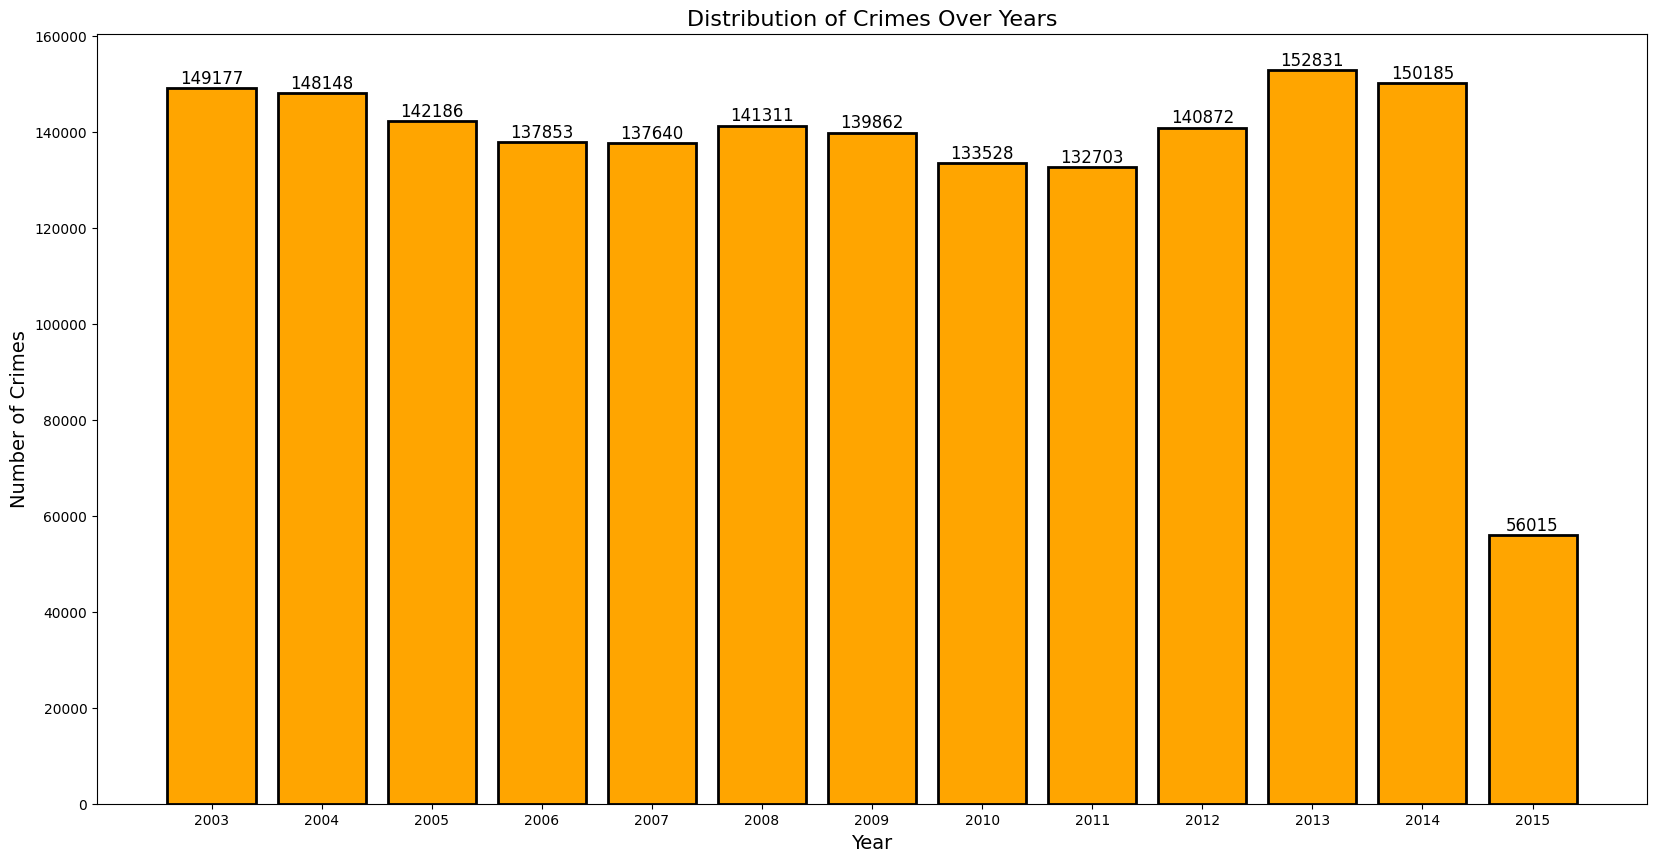

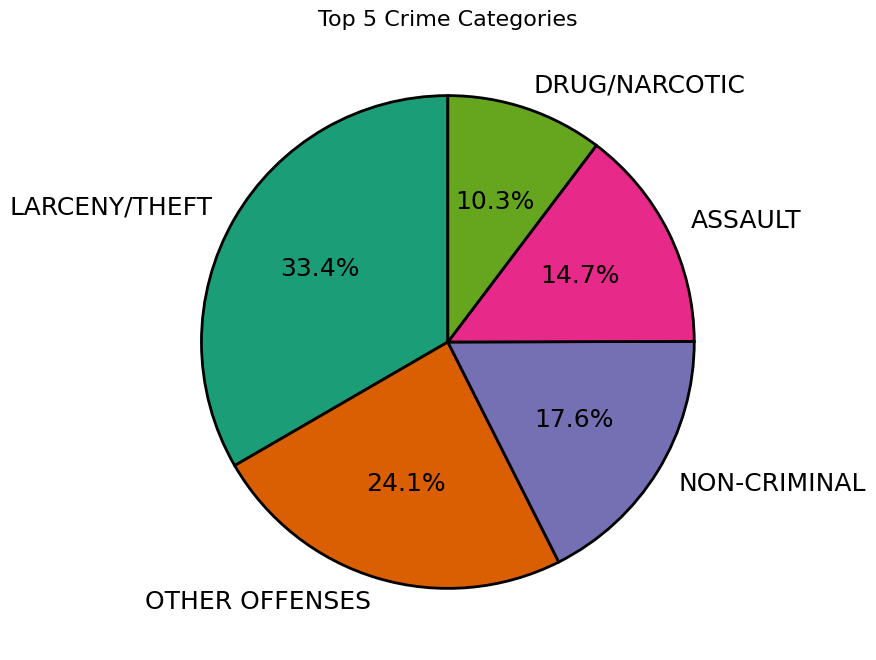

In [4]:
# number of crimes par year
plt.figure(figsize=(20, 10))
year_counts = combined_data['Year'].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color='orange', edgecolor='black', linewidth=2)
for i, count in zip(year_counts.index, year_counts.values):
    plt.text(i, count + 200, str(count), ha='center', va='bottom', fontsize=12, zorder=2)

plt.title('Distribution of Crimes Over Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xticks(year_counts.index)
plt.show()

# the most highest 5 types of crimes
crime_counts = combined_data['Category'].value_counts().head(5)
plt.figure(figsize=(8, 8))
plt.pie(crime_counts, labels=crime_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Dark2.colors, wedgeprops={'edgecolor': 'black', 'linewidth': 2}, textprops={'color': 'black', 'fontsize': 18})
plt.title('Top 5 Crime Categories', fontsize=16)
plt.show()




**Youssef abdelkader's Part**

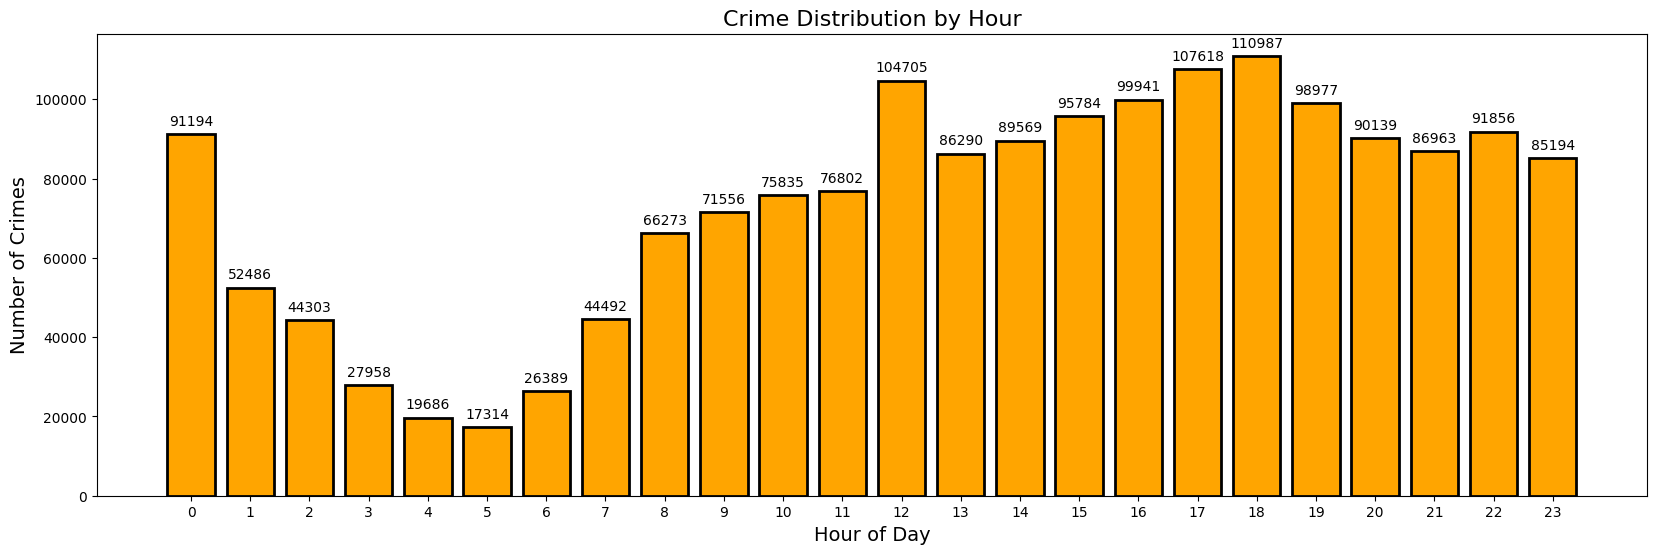

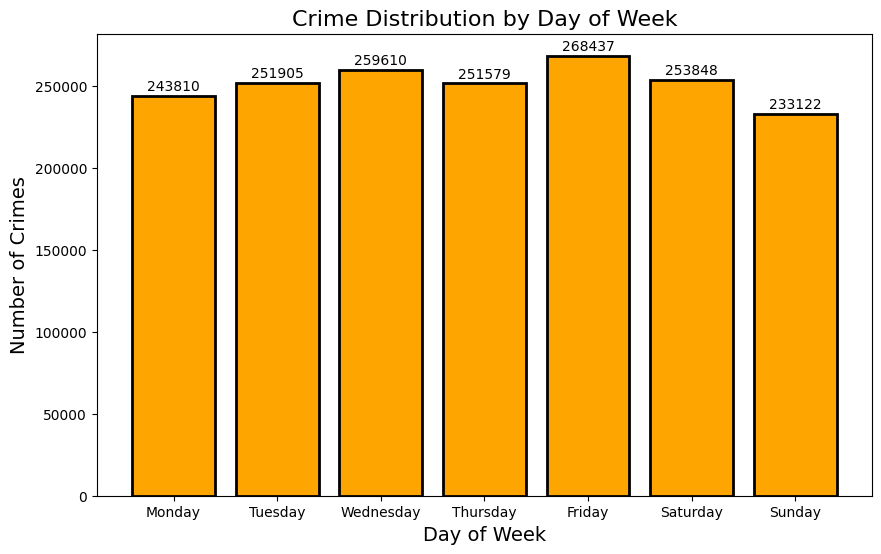

In [5]:
#crime distribution in a day
plt.figure(figsize=(20, 6))
crime_by_hour = combined_data['Hour'].value_counts().sort_index()
plt.bar(crime_by_hour.index, crime_by_hour.values, color='orange', edgecolor='black', linewidth=2)
for i, count in enumerate(crime_by_hour.values):
    plt.text(crime_by_hour.index[i], count + 5000, str(count), ha='center', va='top', fontsize=10, zorder=2)
plt.title('Crime Distribution by Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xticks(crime_by_hour.index)
plt.show()

#crime distribution in a week
crime_by_day = combined_data['DayOfWeek'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(crime_by_day.index, crime_by_day.values, color='orange', edgecolor='black', linewidth=2)
for i, count in enumerate(crime_by_day.values):
    plt.text(crime_by_day.index[i], count + 10000, str(count), ha='center', va='top', fontsize=10, zorder=2)
plt.title('Crime Distribution by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Number of Crimes', fontsize=14)
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()


**Mohamed Hamoda's part**

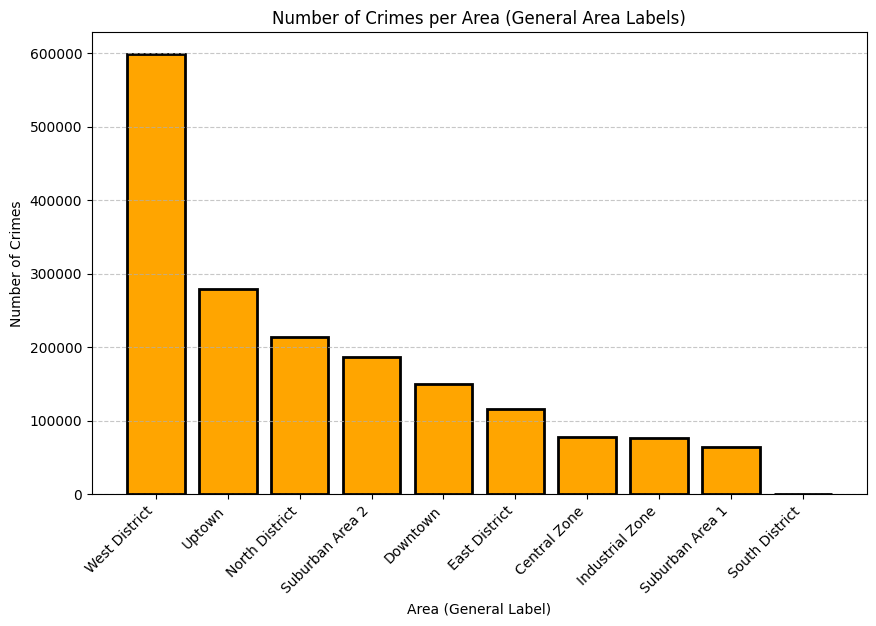

In [6]:
num_clusters = 10  

coords = combined_data[['X', 'Y']].values
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
combined_data['Area'] = kmeans.fit_predict(coords)

area_labels = {
    0: 'North District',
    1: 'South District',
    2: 'East District',
    3: 'West District',
    4: 'Central Zone',
    5: 'Uptown',
    6: 'Downtown',
    7: 'Suburban Area 1',
    8: 'Suburban Area 2',
    9: 'Industrial Zone'
}
combined_data['Area_Label'] = combined_data['Area'].map(area_labels)
crimes_per_area = combined_data['Area_Label'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(crimes_per_area.index, crimes_per_area.values, color='orange', edgecolor='black', linewidth=2)

plt.title('Number of Crimes per Area (General Area Labels)')
plt.xlabel('Area (General Label)')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


**Abdalla Ahmed's Part**

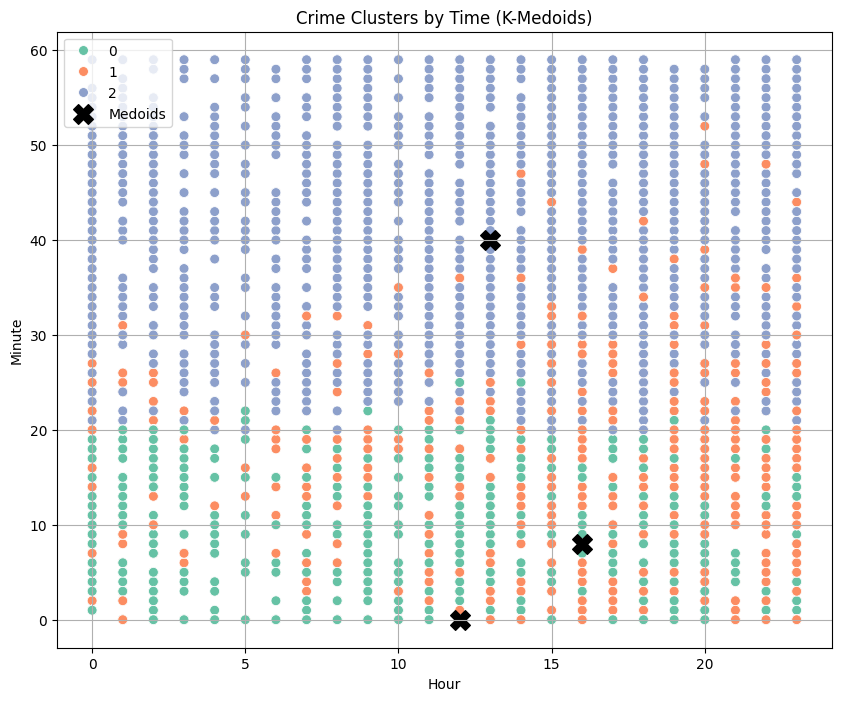

In [7]:
sampled_data = combined_data.dropna(subset=['Category']).sample(n=10000, random_state=42)

features = ['Hour', 'Minute', 'Day', 'DayOfWeek', 'Month']
X = sampled_data[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmedoids = KMedoids(n_clusters=k, random_state=42)
kmedoids.fit(X_scaled)

sampled_data['Cluster'] = kmedoids.labels_

plt.figure(figsize=(10, 8))
sns.scatterplot(data=sampled_data, x='Hour', y='Minute', hue='Cluster', palette='Set2', s=50)
medoids = scaler.inverse_transform(kmedoids.cluster_centers_)
plt.scatter(medoids[:, 0], medoids[:, 1], c='black', marker='X', s=200, label='Medoids')
plt.title("Crime Clusters by Time (K-Medoids)")
plt.xlabel("Hour")
plt.ylabel("Minute")
plt.legend()
plt.grid(True)
plt.show()


**Youssef amr's part**

**Hamouda's visualization but butter**

In [8]:
sampled_data = combined_data.sample(n=5000, random_state=42)
sampled_data['DayOfWeek'] = sampled_data['DayOfWeek'].astype(str).str.strip().str.title()

day_colors = {
    'Monday': 'red',
    'Tuesday': 'blue',
    'Wednesday': 'green',
    'Thursday': 'purple',
    'Friday': 'orange',
    'Saturday': 'pink',
    'Sunday': 'yellow'
}

avg_lat = sampled_data['Y'].mean()
avg_lon = sampled_data['X'].mean() 

for day in sampled_data['DayOfWeek'].unique():
    day_data = sampled_data[sampled_data['DayOfWeek'] == day]
    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=12)
    marker_cluster = MarkerCluster().add_to(m)
    for _, row in day_data.iterrows():
        popup_content = f"Category: {row['Category']}<br>Hour: {row['Hour']}"
        folium.Marker(
            location=[row['Y'], row['X']],
            popup=popup_content,
            icon=folium.Icon(color=day_colors.get(day, 'orange'), icon='info-sign')
        ).add_to(marker_cluster)
    map_filename = f'{calendar.day_name[int(day)]}_crime_map.html'
    m.save(map_filename)
    print(f"Map for {calendar.day_name[int(day)]} saved as '{map_filename}'")

Map for Wednesday saved as 'Wednesday_crime_map.html'
Map for Sunday saved as 'Sunday_crime_map.html'
Map for Saturday saved as 'Saturday_crime_map.html'
Map for Tuesday saved as 'Tuesday_crime_map.html'
Map for Friday saved as 'Friday_crime_map.html'
Map for Thursday saved as 'Thursday_crime_map.html'
Map for Monday saved as 'Monday_crime_map.html'


**Model**

In [9]:
df = combined_data.copy()


features = ['DayOfWeek', 'PdDistrict', 'X', 'Y', 'Hour', 'Block', 'Area']
target = 'Category'

min_samples = 2
value_counts = df[target].value_counts()
valid_categories = value_counts[value_counts >= min_samples].index
df = df[df[target].isin(valid_categories)]

encoders = {}
for col in ['DayOfWeek', 'PdDistrict']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le


target_encoder = LabelEncoder()
df[target] = target_encoder.fit_transform(df[target])

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


labels = np.unique(y_test)
target_classes = target_encoder.inverse_transform(labels)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(
    y_test, 
    y_pred,
    labels=labels,
    target_names=target_classes
))

def predict_crime(crime_details):
    input_df = pd.DataFrame([crime_details])

    for col in ['DayOfWeek', 'PdDistrict']:
        if col in crime_details:
            val = str(crime_details[col])
            input_df[col] = encoders[col].transform([val])[0] if val in encoders[col].classes_ else -1

    for col in features:
        if col not in input_df:
            input_df[col] = 0 if col in ['DayOfWeek', 'PdDistrict'] else df[col].median()
    
    return target_encoder.inverse_transform(model.predict(input_df))[0]

crime_example = {
    'DayOfWeek': 'Monday',
    'PdDistrict': 'DOWNTOWN',
    'X': -122.4194,
    'Y': 137.7749,
    'Hour': 0,
    'Block': 1,
    'Area' : 8
}
print(f"\nPredicted Crime: {predict_crime(crime_example)}")

Model Accuracy: 23.71%

Classification Report:


c:\Users\YoussefAmr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\YoussefAmr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\YoussefAmr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00       456
                    ASSAULT       0.00      0.00      0.00     23097
                 BAD CHECKS       0.00      0.00      0.00       113
                    BRIBERY       0.00      0.00      0.00        90
                   BURGLARY       0.00      0.00      0.00     11049
         DISORDERLY CONDUCT       0.00      0.00      0.00      1241
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00       707
              DRUG/NARCOTIC       0.27      0.30      0.29     16237
                DRUNKENNESS       0.00      0.00      0.00      1272
               EMBEZZLEMENT       0.00      0.00      0.00       346
                  EXTORTION       0.00      0.00      0.00        71
            FAMILY OFFENSES       0.00      0.00      0.00       132
     FORGERY/COUNTERFEITING       0.00      0.00      0.00      3135
                      FRAUD      

**clustering**

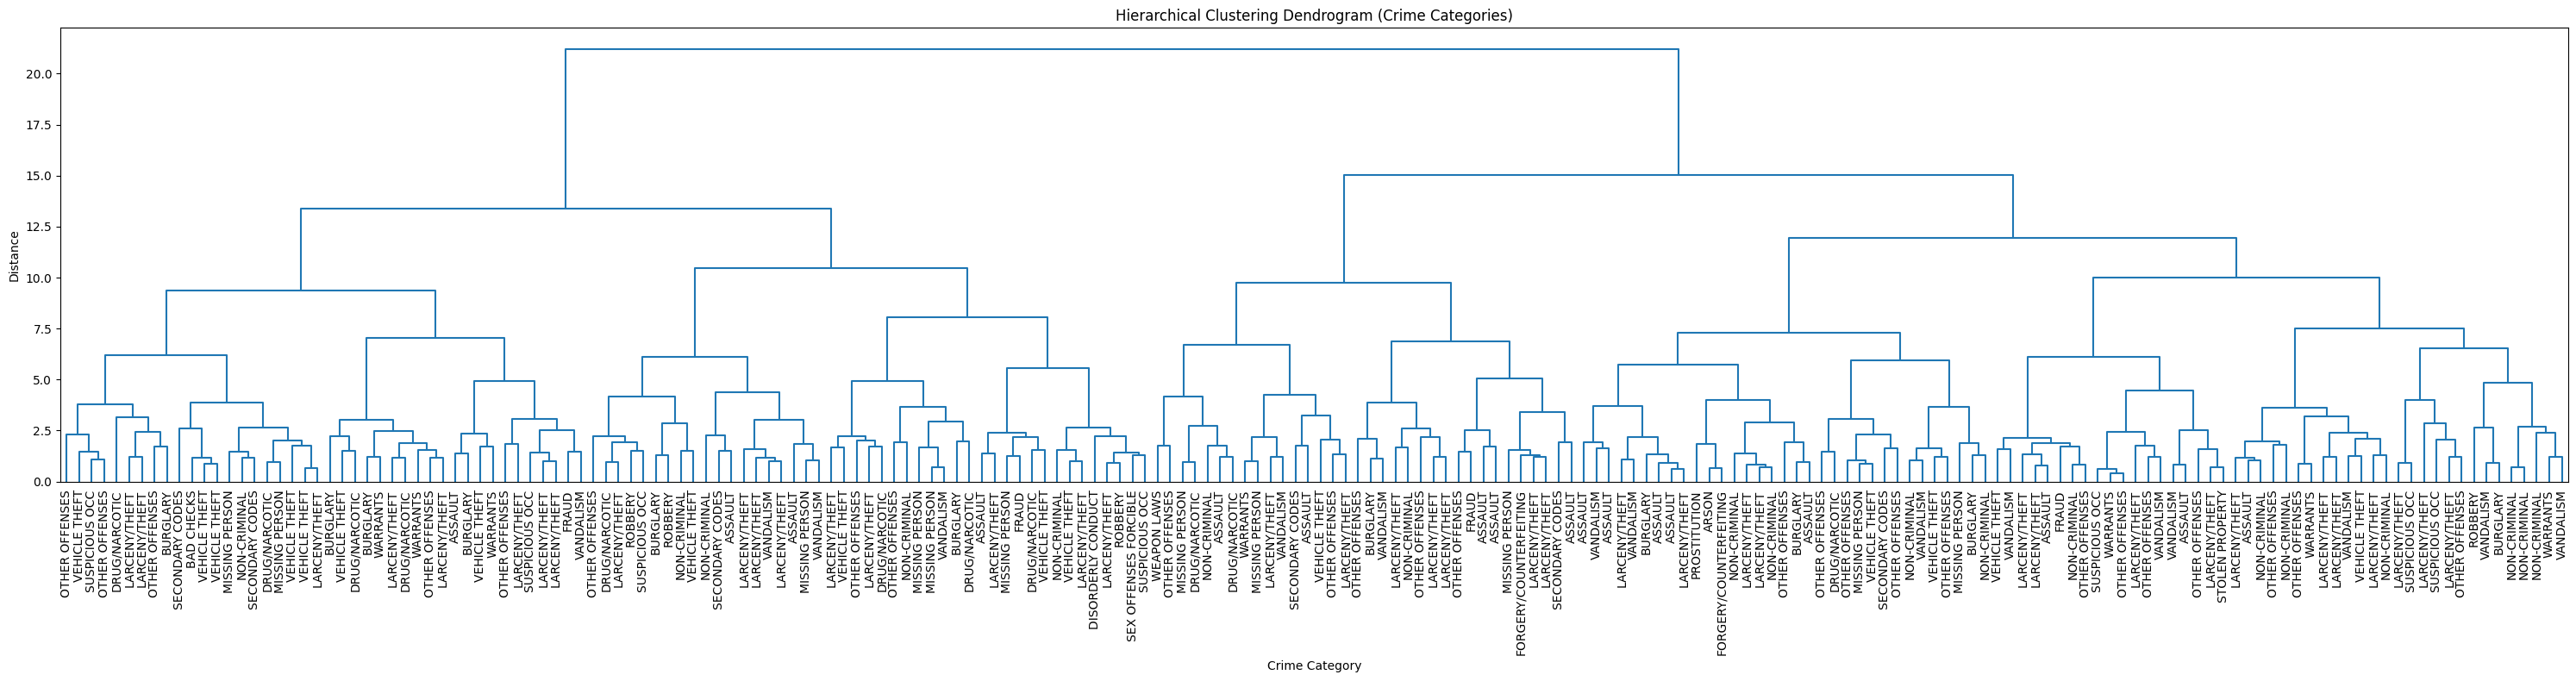

In [10]:
combined_data = combined_data.dropna(subset=['Category'])
features = ['Hour', 'Minute', 'Day', 'DayOfWeek', 'Month', 'Year', 'n_days']
X = combined_data[features]
y = combined_data['Category']

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

sample_size = 200
sampled_data = X.sample(n=sample_size, random_state=42)
sampled_labels = y.loc[sampled_data.index].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sampled_data)
linkage_matrix = linkage(X_scaled, method='ward')


plt.figure(figsize=(30, 8))
dendrogram(
    linkage_matrix,
    labels=sampled_labels,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0
)

plt.title("Hierarchical Clustering Dendrogram (Crime Categories)")
plt.xlabel("Crime Category")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()
